In [1]:
# EDA
import pandas as pd
import pingouin as pg
import plotly.express as px
import plotly.figure_factory as ff
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Otimização de Hiperparâmetros
import optuna

### Loading Dataset

In [2]:
df_fraud = pd.read_csv('./datasets/transacoes_fraude.csv')

### EDA

In [3]:
df_fraud.head(10)

,Cliente,Tipo de Transacao,Valor da Transacao,Valor Anterior a Transacao,Valor Apos a Transacao,Horario da Transacao,Classe
0,cliente1D4F0B,Saque,390.39,5446.75,5056.36,2023-03-14T07:29:28.256579,0
1,clienteCF3D89,Saque,3272.03,12167.89,8895.86,2023-02-12T17:54:09.119410,0
2,cliente0F0D32,PIX,4905.72,8217.63,3311.91,2023-10-03T17:31:42.087599,0
3,clienteFCC0EA,PIX,3073.23,7833.16,4759.93,2024-05-23T17:57:02.055680,0
4,cliente9BA227,PIX,4233.03,6920.82,2687.79,2022-10-07T17:30:36.879557,0
5,cliente62C357,Débito,4848.49,7354.41,2505.92,2025-07-08T19:16:37.207970,0
6,cliente320C76,Crédito,1600.44,7296.87,5696.43,2024-09-07T02:23:16.975044,0
7,cliente32CB58,Crédito,1296.71,10562.92,9266.21,2023-08-28T23:09:19.817457,0
8,cliente67AFD9,Débito,1187.35,10935.18,9747.83,2024-05-21T09:01:08.163132,0
9,cliente84F77D,PIX,3271.51,3405.61,134.10,2022-09-26T10:33:12.415982,0


In [4]:
df_fraud.info()

<class 'pandas.DataFrame'>
RangeIndex: 13000 entries, 0 to 12999
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Cliente                     13000 non-null  str    
 1   Tipo de Transacao           13000 non-null  str    
 2   Valor da Transacao          13000 non-null  float64
 3   Valor Anterior a Transacao  13000 non-null  float64
 4   Valor Apos a Transacao      13000 non-null  float64
 5   Horario da Transacao        13000 non-null  str    
 6   Classe                      13000 non-null  int64  
dtypes: float64(3), int64(1), str(3)
memory usage: 711.1 KB


In [5]:
df_fraud['Tipo de Transacao'].unique()

<StringArray>
['Saque', 'PIX', 'Débito', 'Crédito']
Length: 4, dtype: str

### Categorical features and target distribuition

In [6]:
target_count = df_fraud['Classe'].value_counts()
target_count

Classe
0    11570
1     1430
Name: count, dtype: int64

In [7]:
px.bar(target_count, color=target_count.index)

In [8]:
transaction_type_count = df_fraud['Tipo de Transacao'].value_counts()
px.bar(transaction_type_count, color=transaction_type_count.index)

### Numerical features distribuition

In [9]:
px.histogram(df_fraud, x='Valor Anterior a Transacao')

In [10]:
px.histogram(df_fraud, x='Valor Apos a Transacao')

### Numerical features outliers

In [11]:
px.box(df_fraud, x='Classe', y='Valor da Transacao')

In [12]:
px.box(df_fraud, x='Classe', y='Valor Anterior a Transacao')

In [13]:
px.box(df_fraud, x='Classe', y='Valor Apos a Transacao')


In [14]:

df_fraud['Horario da Transacao'] = pd.to_datetime(df_fraud['Horario da Transacao'])

df_fraud['Hora'] = df_fraud['Horario da Transacao'].dt.hour
df_fraud['Dia Semana'] = df_fraud['Horario da Transacao'].dt.dayofweek  # 0=segunda, 6=domingo
df_fraud['Mes'] = df_fraud['Horario da Transacao'].dt.month

df_fraud = df_fraud.drop(columns=['Horario da Transacao'])

In [15]:
df_fraud.groupby('Classe')['Hora'].describe()


,count,mean,std,min,25%,50%,75%,max
Classe,,,,,,,,
0,11570.0,11.426707,6.927594,0.0,5.0,11.0,17.0,23.0
1,1430.0,9.797902,7.737406,0.0,3.0,8.0,17.0,23.0


In [16]:
df_fraud.groupby('Classe')['Dia Semana'].describe()


,count,mean,std,min,25%,50%,75%,max
Classe,,,,,,,,
0,11570.0,2.998617,2.003583,0.0,1.0,3.0,5.0,6.0
1,1430.0,2.965734,2.017995,0.0,1.0,3.0,5.0,6.0


In [17]:
df_fraud.groupby('Classe')['Mes'].describe()

,count,mean,std,min,25%,50%,75%,max
Classe,,,,,,,,
0,11570.0,6.563699,3.459627,1.0,4.0,7.0,10.0,12.0
1,1430.0,6.499301,3.478968,1.0,3.0,7.0,10.0,12.0


### CrossTab Categorical

In [18]:
crosstab_transaction_type = pd.crosstab(
    df_fraud['Classe'], 
    df_fraud['Tipo de Transacao'], 
    normalize='columns', 
    margins=True
)
transaction_type_table = ff.create_table(crosstab_transaction_type.round(3))
transaction_type_table.show()

### Chi2

In [19]:
expected_value, observed_value, statistics = pg.chi2_independence(df_fraud, 'Classe', 'Tipo de Transacao')

In [20]:
expected_value

Tipo de Transacao,Crédito,Débito,PIX,Saque
Classe,,,,
0,2840.88,2928.1,2913.86,2887.16
1,351.12,361.9,360.14,356.84


In [21]:
observed_value

Tipo de Transacao,Crédito,Débito,PIX,Saque
Classe,,,,
0,2875,2917,2878,2900
1,317,373,396,344


In [22]:
statistics

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,8.639030,3.0,0.034496,0.025779,0.691482
1,cressie-read,0.666667,8.638566,3.0,0.034503,0.025778,0.691456
2,log-likelihood,0.000000,8.641403,3.0,0.034459,0.025782,0.691615
3,freeman-tukey,-0.500000,8.646833,3.0,0.034374,0.025790,0.691920
4,mod-log-likelihood,-1.000000,8.655103,3.0,0.034246,0.025803,0.692383
5,neyman,-2.000000,8.680215,3.0,0.033859,0.025840,0.693787


### Model

In [23]:
X = df_fraud.drop(columns=['Classe'])
y = df_fraud['Classe']

In [24]:
categorical_feature = ['Valor da Transacao']

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_feature)
    ]
)

fraud_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier())
])


### Cross Validate

In [25]:
cv_folds = StratifiedKFold(n_splits=3, shuffle=True, random_state=51)
metrics_result = cross_validate(fraud_model, X, y, cv=cv_folds, scoring=['accuracy', 'recall'], return_estimator=True)

In [26]:
metrics_result

{'fit_time': array([1.59631968, 1.52633238, 1.55157542]),
 'score_time': array([0.02271867, 0.01694584, 0.01767206]),
 'estimator': [Pipeline(steps=[('preprocessor',
                   ColumnTransformer(transformers=[('cat',
                                                    Pipeline(steps=[('imputer',
                                                                     SimpleImputer(strategy='most_frequent')),
                                                                    ('onehot',
                                                                     OneHotEncoder(handle_unknown='ignore'))]),
                                                    ['Valor da Transacao'])])),
                  ('classifier', DecisionTreeClassifier())]),
  Pipeline(steps=[('preprocessor',
                   ColumnTransformer(transformers=[('cat',
                                                    Pipeline(steps=[('imputer',
                                                                     SimpleIm

In [27]:
metrics_result['test_accuracy'].mean()

np.float64(0.8885384247192634)

In [28]:
metrics_result['test_recall'].mean()

np.float64(0.0)

### Metrics

In [29]:
y_pred = cross_val_predict(fraud_model, X, y, cv=cv_folds)

In [30]:
classification_report_str = classification_report(y, y_pred)
print(f'Relatório de Classificação: \n{classification_report_str}')

Relatório de Classificação: 
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     11570
           1       0.00      0.00      0.00      1430

    accuracy                           0.89     13000
   macro avg       0.44      0.50      0.47     13000
weighted avg       0.79      0.89      0.84     13000



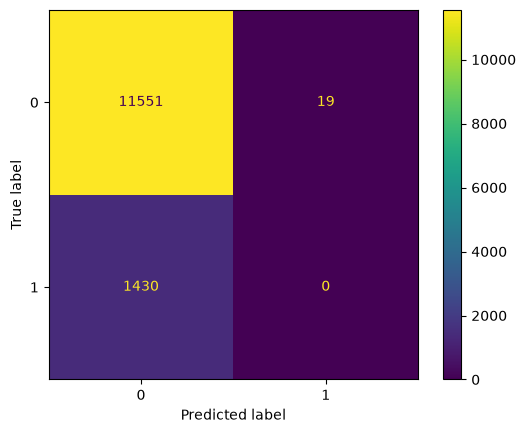

In [38]:
ConfusionMatrixDisplay.from_predictions(y, y_pred)
plt.show()

### Tuning Hiperparams

In [41]:
def decisiontree_optuna(trial):
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_depth = trial.suggest_int('max_depth', 2, 8)
    fraud_model.set_params(classifier__min_samples_leaf=min_samples_leaf)
    fraud_model.set_params(classifier__max_depth=max_depth)

    scores = cross_val_score(fraud_model, X, y, cv=cv_folds, scoring='accuracy')
    return scores.mean()


In [42]:
study_decisiontree = optuna.create_study(direction='maximize')
study_decisiontree.optimize(decisiontree_optuna, n_trials=100)

[I 2026-07-29 15:11:55,900] A new study created in memory with name: no-name-dc53666d-f8b7-4ce0-980d-53082e62eb1e
[I 2026-07-29 15:11:56,124] Trial 0 finished with value: 0.8900000046150297 and parameters: {'min_samples_leaf': 12, 'max_depth': 7}. Best is trial 0 with value: 0.8900000046150297.
[I 2026-07-29 15:11:56,169] Trial 1 finished with value: 0.8900000046150297 and parameters: {'min_samples_leaf': 14, 'max_depth': 3}. Best is trial 0 with value: 0.8900000046150297.
[I 2026-07-29 15:11:56,215] Trial 2 finished with value: 0.8900000046150297 and parameters: {'min_samples_leaf': 3, 'max_depth': 7}. Best is trial 0 with value: 0.8900000046150297.
[I 2026-07-29 15:11:56,280] Trial 3 finished with value: 0.8900000046150297 and parameters: {'min_samples_leaf': 9, 'max_depth': 4}. Best is trial 0 with value: 0.8900000046150297.
[I 2026-07-29 15:11:56,329] Trial 4 finished with value: 0.8900000046150297 and parameters: {'min_samples_leaf': 8, 'max_depth': 8}. Best is trial 0 with value:

In [43]:
print(f'Best Accuracy: {study_decisiontree.best_value}')
print(f'Best Paramns: {study_decisiontree.best_params}')

Best Accuracy: 0.8900000046150297
Best Paramns: {'min_samples_leaf': 12, 'max_depth': 7}


### Training model with the best paramns

In [50]:
fraud_model.set_params( classifier__min_samples_leaf=study_decisiontree.best_params['min_samples_leaf'], classifier__max_depth=study_decisiontree.best_params['max_depth'] )

y_pred = cross_val_predict(fraud_model, X, y, cv=cv_folds)
print(classification_report(y, y_pred))

print(confusion_matrix(y, y_pred))

fraud_model.fit(X, y)

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     11570
           1       0.00      0.00      0.00      1430

    accuracy                           0.89     13000
   macro avg       0.45      0.50      0.47     13000
weighted avg       0.79      0.89      0.84     13000

[[11570     0]
 [ 1430     0]]


c:\Users\grecc\.virtualenvs\bank-transaction-fraud-classifier-A1BJUIGb\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\grecc\.virtualenvs\bank-transaction-fraud-classifier-A1BJUIGb\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\grecc\.virtualenvs\bank-transaction-fraud-classifier-A1BJUIGb\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Cliente','Tipo de Transacao','Valor da Transacao',...,'Hora', 'Dia Semana','Mes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all

## Final Considerations
###  - **Type of Transaction** was the only categorical feature with a statistically significant association with the target according to **Pearson’s Chi-Square test (p = 0.034)**. 
### - The other categorical variables were either **independent from the target** or showed only a **weak relationship** with fraud occurrence. 
### - The initial Decision Tree model achieved **~88% accuracy**, but it **failed to identify any fraudulent transaction**. 
### - The confusion matrix revealed a strong bias toward the **majority class (non-fraud)**, resulting in **recall = 0 for the fraud class**. 
### - Hyperparameter tuning was performed using **Optuna** with **Stratified K-Fold cross-validation**. 
### - After tuning, the model slightly improved the classification of **non-fraud transactions**, but the **fraud recall remained 0**. - The results suggest that the main challenge is **class imbalance and the limited predictive information of the available features**, rather than overfitting.